# Easy Time Series Dataset Generator (`dataset_ts_easy_50.pkl`)

Generates 50 simple time series, each a **sine wave + linear trend + noise**.

Each sample: `y(t) = slope * t + amplitude * sin(2π * frequency * t) + ε(t)`

Parameters vary across samples:
- **slope**: negative, zero, or positive (decreasing / flat / increasing trend)
- **amplitude**: controls the magnitude of the sine oscillation
- **frequency**: controls how many cycles appear in the window
- **noise**: small Gaussian noise for realism

All series are **mean-centered around 0** with 600 data points on a daily `DatetimeIndex`.

In [10]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Define generation parameters

In [11]:
N_SAMPLES = 50
N_POINTS = 600
START_DATE = '2024-01-01'
FREQ = 'D'
MASTER_SEED = 2026

rng = np.random.default_rng(MASTER_SEED)

# Parameter ranges
# slope per normalized time unit (t in [0,1]): controls linear trend magnitude
slope_range = (-2.5, 2.5)        # negative = decreasing, 0 = flat, positive = increasing
amplitude_range = (0.2, 2.0)     # sine wave amplitude
frequency_range = (1.0, 12.0)    # number of full cycles in the window
noise_std_range = (0.05, 0.15)   # noise as fraction of amplitude

# Generate parameter sets
slopes = rng.uniform(*slope_range, size=N_SAMPLES)
amplitudes = rng.uniform(*amplitude_range, size=N_SAMPLES)
frequencies = rng.uniform(*frequency_range, size=N_SAMPLES)
noise_fracs = rng.uniform(*noise_std_range, size=N_SAMPLES)
seeds = rng.choice(range(1, 100000), size=N_SAMPLES, replace=False)

# Force a few samples to be exactly flat (slope=0) for variety
flat_indices = rng.choice(N_SAMPLES, size=8, replace=False)
slopes[flat_indices] = 0.0

print(f"Slope range:     [{slopes.min():.3f}, {slopes.max():.3f}]")
print(f"Amplitude range: [{amplitudes.min():.3f}, {amplitudes.max():.3f}]")
print(f"Frequency range: [{frequencies.min():.3f}, {frequencies.max():.3f}]")
print(f"Flat samples:    {sorted(flat_indices)}")

Slope range:     [-2.436, 2.234]
Amplitude range: [0.203, 1.982]
Frequency range: [1.360, 11.598]
Flat samples:    [np.int64(0), np.int64(1), np.int64(5), np.int64(7), np.int64(10), np.int64(15), np.int64(22), np.int64(44)]


## 2. Generate the dataset

In [12]:
time_index = pd.date_range(start=START_DATE, periods=N_POINTS, freq=FREQ, name='time')
t_norm = np.linspace(0, 1, N_POINTS)  # normalized time in [0, 1]

dataset = []

for i in range(N_SAMPLES):
    local_rng = np.random.default_rng(int(seeds[i]))

    slope = slopes[i]
    amp = amplitudes[i]
    freq = frequencies[i]
    noise_std = noise_fracs[i] * amp

    # Signal: linear trend + sine wave + noise
    linear = slope * t_norm
    sine = amp * np.sin(2 * np.pi * freq * t_norm)
    noise = local_rng.normal(0, noise_std, size=N_POINTS)

    y = linear + sine + noise

    # Mean-center the signal
    y = y - y.mean()

    series = pd.Series(data=y, index=time_index, name='value', dtype=np.float64)

    # Classify trend type for the name field
    if abs(slope) < 0.01:
        trend_label = 'Flat'
    elif slope > 0:
        trend_label = 'Increasing'
    else:
        trend_label = 'Decreasing'

    dataset.append({
        'series_id': i,
        'unique_id': f'easy_sine_s{i:03d}',
        'category': 'EasySinusoidal',
        'name': f'SineLinear_{trend_label}',
        'anomaly_info': 'No anomalies',
        'source_path': 'generated/easy_sine_dataset',
        'data': series,
    })

print(f"Generated {len(dataset)} samples")
print(f"Series length: {len(dataset[0]['data'])}")
print(f"Keys: {list(dataset[0].keys())}")
print(f"Index name: {dataset[0]['data'].index.name}")
print(f"Value name: {dataset[0]['data'].name}")

Generated 50 samples
Series length: 600
Keys: ['series_id', 'unique_id', 'category', 'name', 'anomaly_info', 'source_path', 'data']
Index name: time
Value name: value


## 3. Verify data properties

In [13]:
means = [d['data'].mean() for d in dataset]
stds = [d['data'].std() for d in dataset]
mins = [d['data'].min() for d in dataset]
maxs = [d['data'].max() for d in dataset]

print(f"Mean of means:  {np.mean(means):.6f}  (should be ~0)")
print(f"Std of means:   {np.std(means):.6f}")
print(f"Avg std:        {np.mean(stds):.3f}")
print(f"Value range:    [{np.min(mins):.3f}, {np.max(maxs):.3f}]")

# Count trend types
from collections import Counter
trend_counts = Counter(d['name'] for d in dataset)
print(f"\nTrend distribution: {dict(trend_counts)}")

Mean of means:  -0.000000  (should be ~0)
Std of means:   0.000000
Avg std:        0.877
Value range:    [-3.819, 3.141]

Trend distribution: {'SineLinear_Flat': 8, 'SineLinear_Decreasing': 23, 'SineLinear_Increasing': 19}


## 4. Visualize a grid of samples

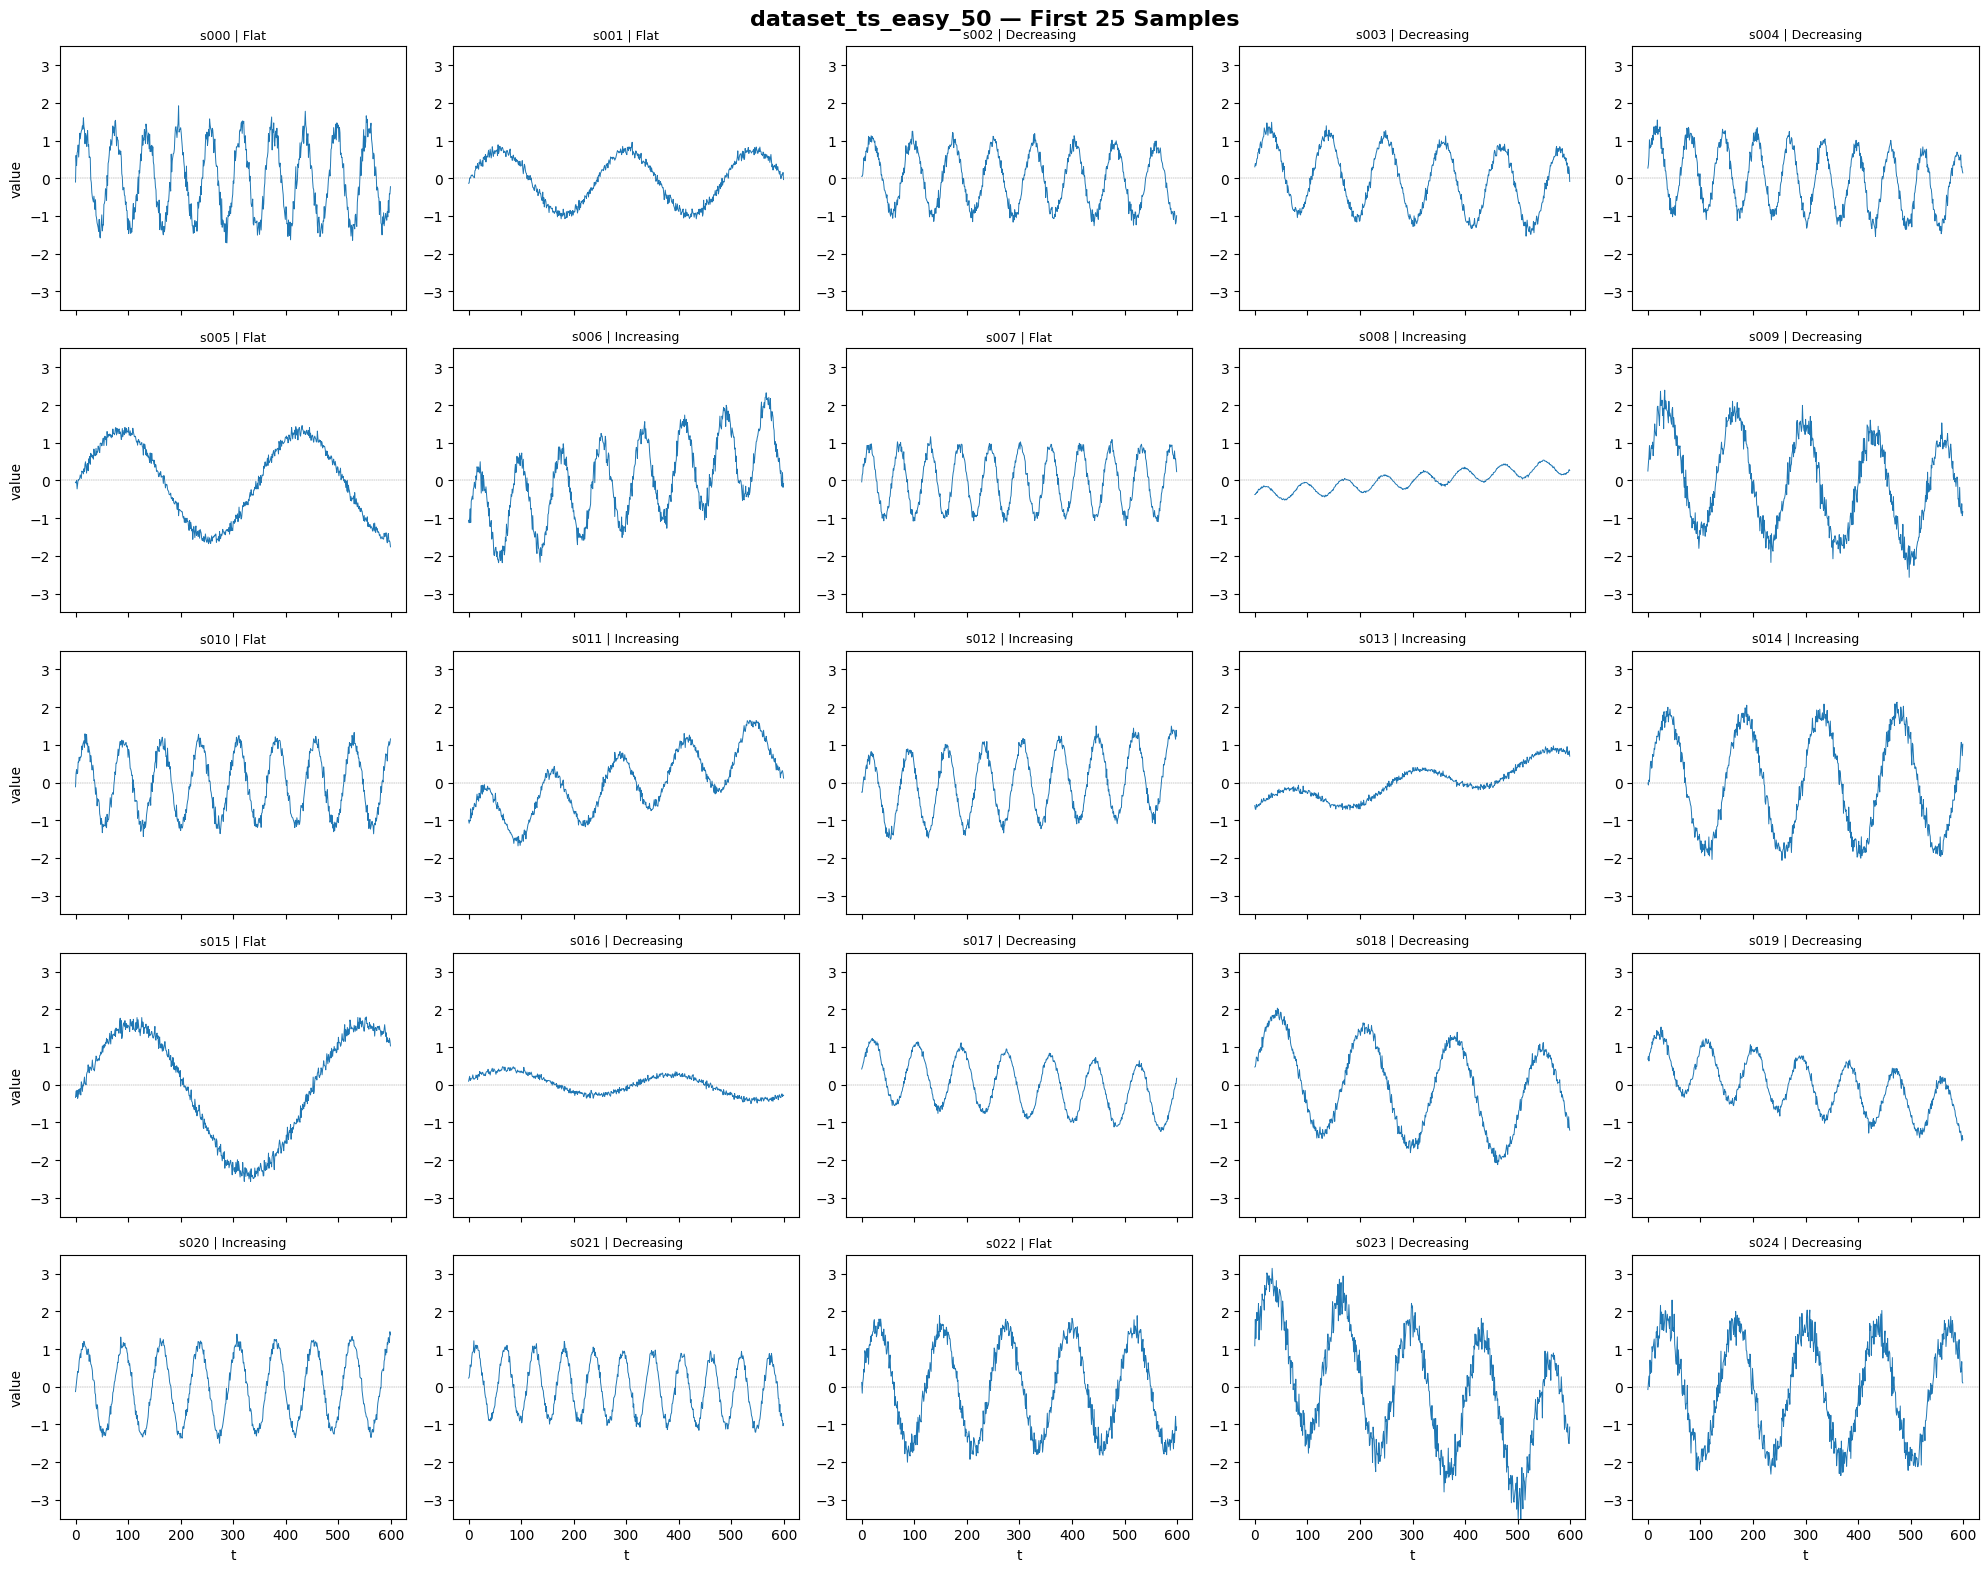

In [14]:
fig, axes = plt.subplots(5, 5, figsize=(20, 16), sharex=True)
fig.suptitle('dataset_ts_easy_50 — First 25 Samples', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx >= min(25, len(dataset)):
        ax.set_visible(False)
        continue
    d = dataset[idx]
    ax.plot(np.arange(N_POINTS), d['data'].values, linewidth=0.7, color='tab:blue')
    ax.set_title(f"s{idx:03d} | {d['name'].split('_')[1]}", fontsize=9)
    ax.set_ylim(-3.5, 3.5)
    ax.axhline(0, color='gray', linewidth=0.3, linestyle='--')
    if idx >= 20:
        ax.set_xlabel('t')
    if idx % 5 == 0:
        ax.set_ylabel('value')

plt.tight_layout()
plt.show()

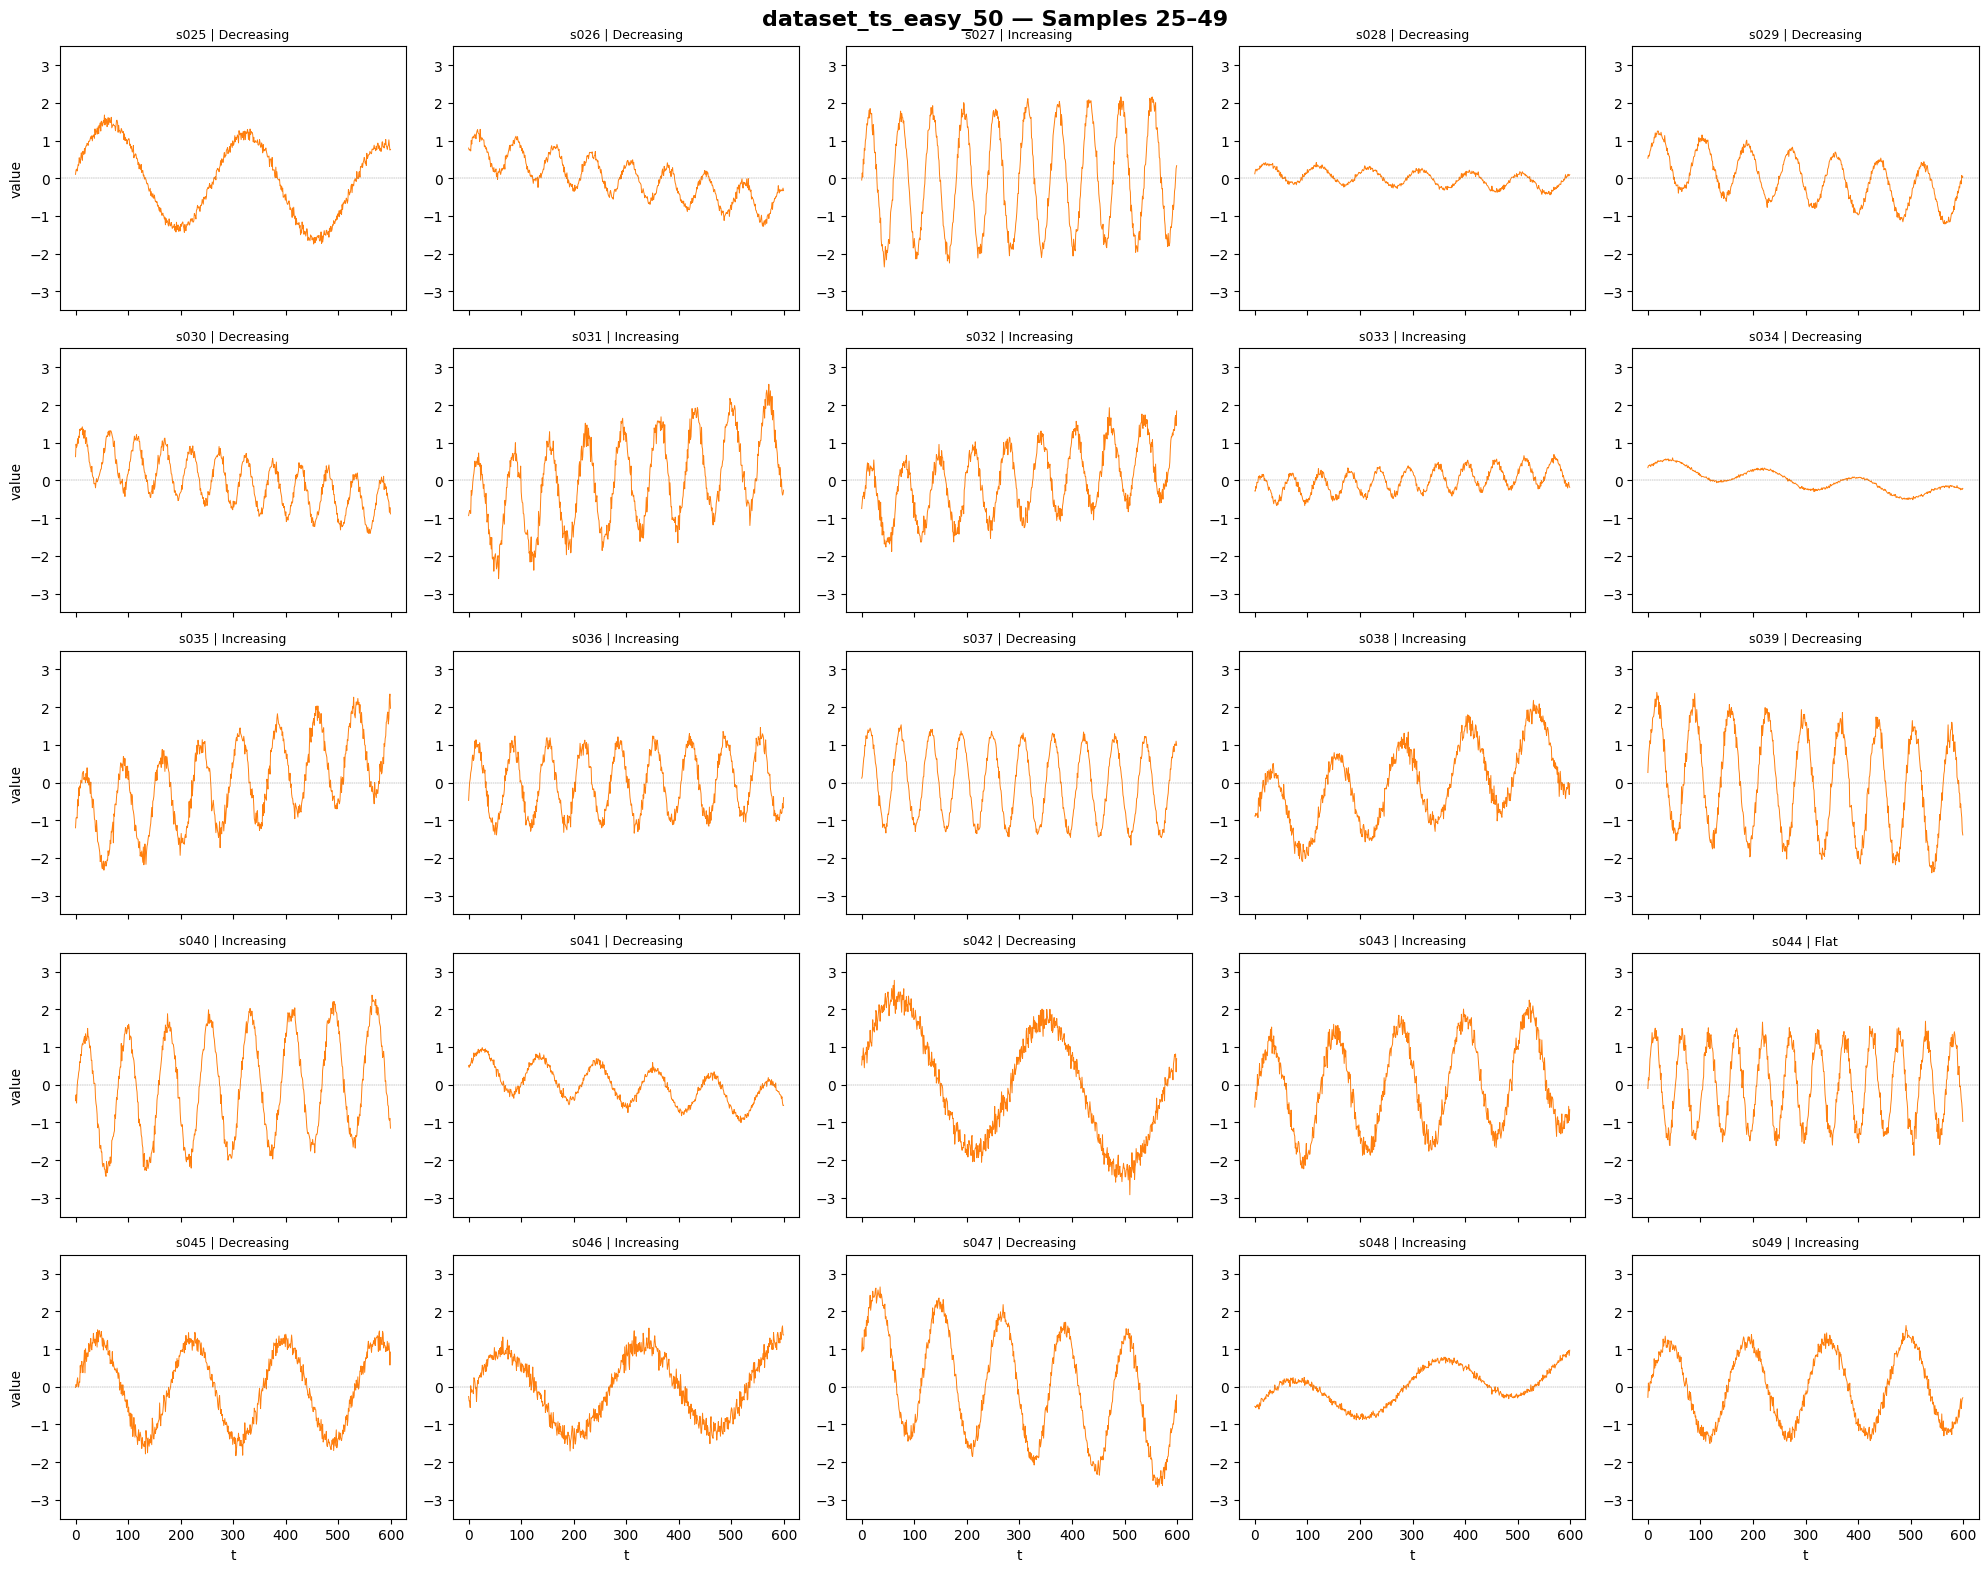

In [15]:
fig, axes = plt.subplots(5, 5, figsize=(20, 16), sharex=True)
fig.suptitle('dataset_ts_easy_50 — Samples 25–49', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    sample_idx = 25 + idx
    if sample_idx >= len(dataset):
        ax.set_visible(False)
        continue
    d = dataset[sample_idx]
    ax.plot(np.arange(N_POINTS), d['data'].values, linewidth=0.7, color='tab:orange')
    ax.set_title(f"s{sample_idx:03d} | {d['name'].split('_')[1]}", fontsize=9)
    ax.set_ylim(-3.5, 3.5)
    ax.axhline(0, color='gray', linewidth=0.3, linestyle='--')
    if idx >= 20:
        ax.set_xlabel('t')
    if idx % 5 == 0:
        ax.set_ylabel('value')

plt.tight_layout()
plt.show()

## 5. Detailed view of representative samples

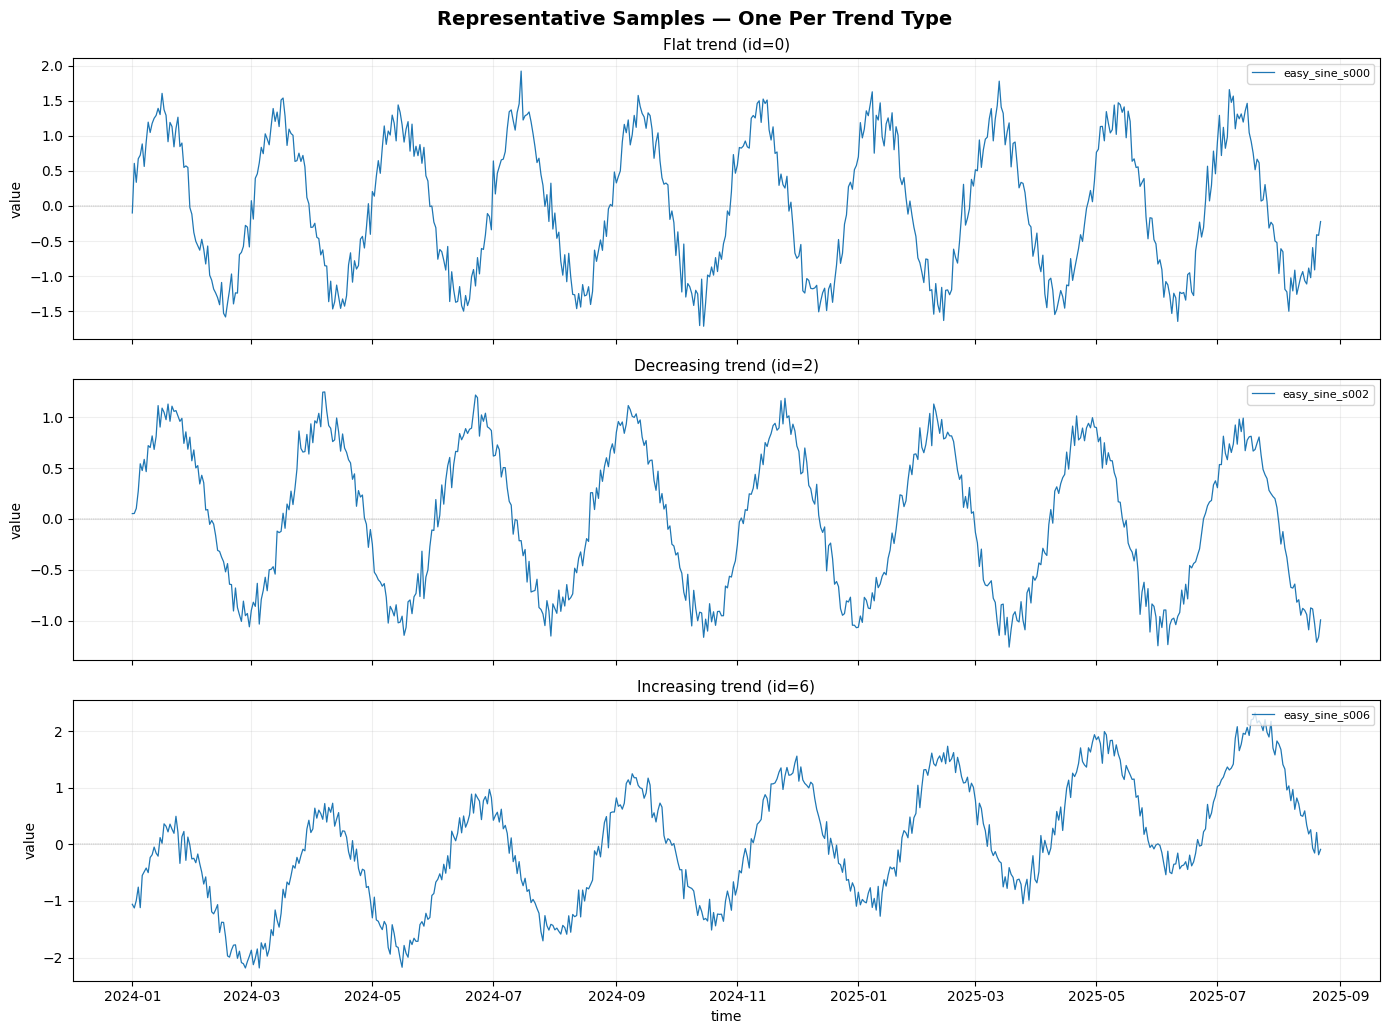

In [16]:
# Pick one of each trend type
examples = {}
for d in dataset:
    label = d['name'].split('_')[1]
    if label not in examples:
        examples[label] = d

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3.5 * len(examples)), sharex=True)
fig.suptitle('Representative Samples — One Per Trend Type', fontsize=14, fontweight='bold')

for ax, (label, d) in zip(axes, examples.items()):
    ax.plot(d['data'].index, d['data'].values, linewidth=0.9, label=f"{d['unique_id']}")
    ax.set_title(f"{label} trend (id={d['series_id']})", fontsize=11)
    ax.set_ylabel('value')
    ax.axhline(0, color='gray', linewidth=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

## 6. Parameter summary table

In [17]:
param_df = pd.DataFrame({
    'series_id': range(N_SAMPLES),
    'slope': slopes,
    'amplitude': amplitudes,
    'frequency': frequencies,
    'noise_frac': noise_fracs,
    'trend_type': [d['name'].split('_')[1] for d in dataset],
    'data_mean': means,
    'data_std': stds,
    'data_min': mins,
    'data_max': maxs,
})
param_df.round(4)

,series_id,slope,amplitude,frequency,noise_frac,trend_type,data_mean,data_std,data_min,data_max
0,0,0.0000,1.3187,9.9567,0.1414,Flat,0.0,0.9581,-1.7140,1.9218
1,1,0.0000,0.8699,2.4824,0.0819,Flat,-0.0,0.6059,-1.0750,0.9558
2,2,-0.1637,0.9563,7.7706,0.1086,Decreasing,-0.0,0.7025,-1.2591,1.2473
3,3,-0.6475,1.0907,5.4312,0.0739,Decreasing,-0.0,0.8026,-1.5344,1.4867
4,4,-0.7254,1.0459,9.4264,0.1168,Decreasing,-0.0,0.7787,-1.5441,1.5470
5,5,0.0000,1.4162,1.7449,0.0628,Flat,-0.0,1.0035,-1.7613,1.4549
6,6,2.0257,1.2389,7.6750,0.1290,Increasing,-0.0,1.0489,-2.1830,2.3236
7,7,0.0000,0.9493,10.4279,0.0923,Flat,-0.0,0.6794,-1.1998,1.1602
8,8,0.7639,0.2032,7.9118,0.0684,Increasing,-0.0,0.2519,-0.5229,0.5395
9,9,-1.0085,1.6293,4.5347,0.1258,Decreasing,-0.0,1.1964,-2.5700,2.3930


## 7. Save to pickle

In [18]:
output_path = Path('dataset_ts_easy_50.pkl')

with open(output_path, 'wb') as f:
    pickle.dump(dataset, f)

print(f"Saved {len(dataset)} samples to {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

# Verify round-trip
with open(output_path, 'rb') as f:
    loaded = pickle.load(f)

assert len(loaded) == N_SAMPLES
assert set(loaded[0].keys()) == {'series_id', 'unique_id', 'category', 'name', 'anomaly_info', 'source_path', 'data'}
assert len(loaded[0]['data']) == N_POINTS
assert loaded[0]['data'].index.name == 'time'
assert loaded[0]['data'].name == 'value'
print("Round-trip verification passed.")

Saved 50 samples to dataset_ts_easy_50.pkl
File size: 488.6 KB
Round-trip verification passed.


## 8. Distribution of values across all samples

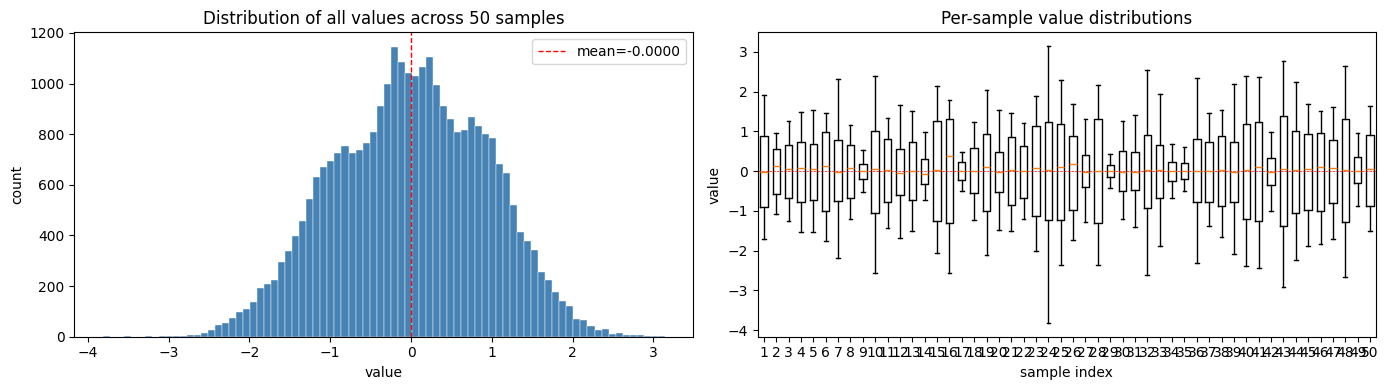

Global mean: -0.000000
Global std:  0.9405
Global range: [-3.819, 3.141]


In [19]:
all_values = np.concatenate([d['data'].values for d in dataset])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_values, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution of all values across 50 samples')
axes[0].set_xlabel('value')
axes[0].set_ylabel('count')
axes[0].axvline(0, color='red', linewidth=1, linestyle='--', label=f'mean={all_values.mean():.4f}')
axes[0].legend()

axes[1].boxplot([d['data'].values for d in dataset], widths=0.6)
axes[1].set_title('Per-sample value distributions')
axes[1].set_xlabel('sample index')
axes[1].set_ylabel('value')
axes[1].axhline(0, color='red', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

print(f"Global mean: {all_values.mean():.6f}")
print(f"Global std:  {all_values.std():.4f}")
print(f"Global range: [{all_values.min():.3f}, {all_values.max():.3f}]")